# Notebook 02 — Métricas iniciales (PSNR / SSIM)

En este cuaderno medimos **PSNR** y **SSIM** entre:

- la imagen **original a color** `I*.jpg` (ground truth), y
- la imagen **colorizada** `I*_color.png` generada a partir de su versión en gris.

Salida:

- Tabla `../eval/tables/metrics.csv` con PSNR/SSIM por imagen.
- Mosaico `../eval/figs/mosaic_metrics.png` con comparaciones visuales.

In [5]:
from pathlib import Path
import numpy as np
import cv2 as cv
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

BASE = Path('..').resolve()
DATA_RAW = (BASE /'Proyecto'/ 'imgs')
DATA_RES = (BASE /'Proyecto'/'imgs_out')
EVAL_T  = BASE /'Proyecto'/ 'eval' / 'tables'
EVAL_F  = BASE /'Proyecto'/ 'eval' / 'figs'

EVAL_T.mkdir(parents=True, exist_ok=True)
EVAL_F.mkdir(parents=True, exist_ok=True)

print('RAW (gt)  =', DATA_RAW)
print('RES (out) =', DATA_RES)
print('TABLAS    =', EVAL_T)
print('FIGURAS   =', EVAL_F)

RAW (gt)  = C:\Users\ander\Desktop\PID\Proyecto\imgs
RES (out) = C:\Users\ander\Desktop\PID\Proyecto\imgs_out
TABLAS    = C:\Users\ander\Desktop\PID\Proyecto\eval\tables
FIGURAS   = C:\Users\ander\Desktop\PID\Proyecto\eval\figs


## Preparación y emparejado de imágenes

Asumimos que el Notebook 01 ya ha generado, para cada `I*.jpg`:

- su versión en gris `I*_gray.jpg` en `../imgs/`,
- su versión colorizada `I*_color.png` en `../imgs_out/`.

En este cuaderno **no modificamos las imágenes**. Solo:

1. Emparejamos cada original `I*.jpg` con su salida `I*_color.*`.
2. Calculamos PSNR y SSIM en color entre ambos.

## Utilidades de carga y emparejado

Definimos funciones auxiliares para leer imágenes en color y
emparejar cada original `I*.jpg` con su correspondiente `I*_color.*`.

In [6]:
def imread_color(path):
    """Lee una imagen en color (BGR)."""
    img = cv.imread(str(path))
    return img  # BGR


def list_pairs():
    """
    Devuelve lista de pares (ruta_gt, ruta_colorizada), emparejando:

    - GT:  ImagenXX.jpg
    - OUT: ImagenXX_color.jpg
    """

    pairs = []

    # 1. Buscar las originales: ImagenXX.jpg
    raw_files = sorted([
        p for p in DATA_RAW.glob("I*")
        if "_gray" not in p.name and "_color" not in p.name and "ansel" not in p.name.lower()
    ])

    for rf in raw_files:
        name = rf.stem  # 'Imagen01'
        color_name = f"{name}_color.jpg"
        color_path = DATA_RES / color_name

        if color_path.exists():
            pairs.append((rf, color_path))
        else:
            print(f"[AVISO] No se encontró {color_name}")

    print(f"Se han emparejado {len(pairs)} imágenes.")
    return pairs

## Cálculo de PSNR y SSIM en color

Para cada par (original, colorizada):

1. Leemos ambas imágenes en color.
2. Ajustamos tamaños si no coinciden.
3. Calculamos PSNR y SSIM **por canal** utilizando las imágenes en color.
4. Guardamos los resultados en `eval/tables/metrics.csv`.

In [7]:
rows = []

pairs = list_pairs()

if not pairs:
    print("No hay pares (GT, colorizada). ¿Has ejecutado el Notebook 01?")
else:
    for raw_p, res_p in pairs:
        gt  = imread_color(raw_p)   # ImagenXX.jpg (BGR)
        out = imread_color(res_p)   # ImagenXX_color.jpg (BGR)

        if gt is None or out is None:
            print(f'[AVISO] No se pudieron leer: {raw_p.name} o {res_p.name}. Se omite.')
            continue

        # Aseguramos que ambas tengan el mismo tamaño
        if gt.shape != out.shape:
            out = cv.resize(out, (gt.shape[1], gt.shape[0]))

        # Convertimos a RGB por claridad
        gt_rgb  = cv.cvtColor(gt, cv.COLOR_BGR2RGB)
        out_rgb = cv.cvtColor(out, cv.COLOR_BGR2RGB)

        # Cálculo de métricas
        psnr_val = psnr(gt_rgb, out_rgb, data_range=255)
        ssim_val = ssim(gt_rgb, out_rgb, data_range=255, channel_axis=-1)

        rows.append({
            'imagen': raw_p.name,  # Ej: Imagen01.jpg
            'psnr': psnr_val,
            'ssim': ssim_val
        })

    # Guardamos y mostramos
    df = pd.DataFrame(rows).sort_values('imagen')
    csv_path = EVAL_T / 'metrics.csv'
    df.to_csv(csv_path, index=False)
    display(df)

Se han emparejado 3 imágenes.


,imagen,psnr,ssim
0,Imagen01.jpg,19.558175,0.818306
1,Imagen02.jpg,18.217422,0.823651
2,Imagen03.jpg,23.781436,0.885787


## Mosaico antes/después (primeras N imágenes)

Mostramos algunas parejas (original, salida colorizada) para tener una
visualización cualitativa rápida del comportamiento del modelo.

CSV  -> C:\Users\ander\Desktop\PID\Proyecto\eval\tables\metrics.csv
FIG  -> C:\Users\ander\Desktop\PID\Proyecto\eval\figs\mosaic_metrics.png


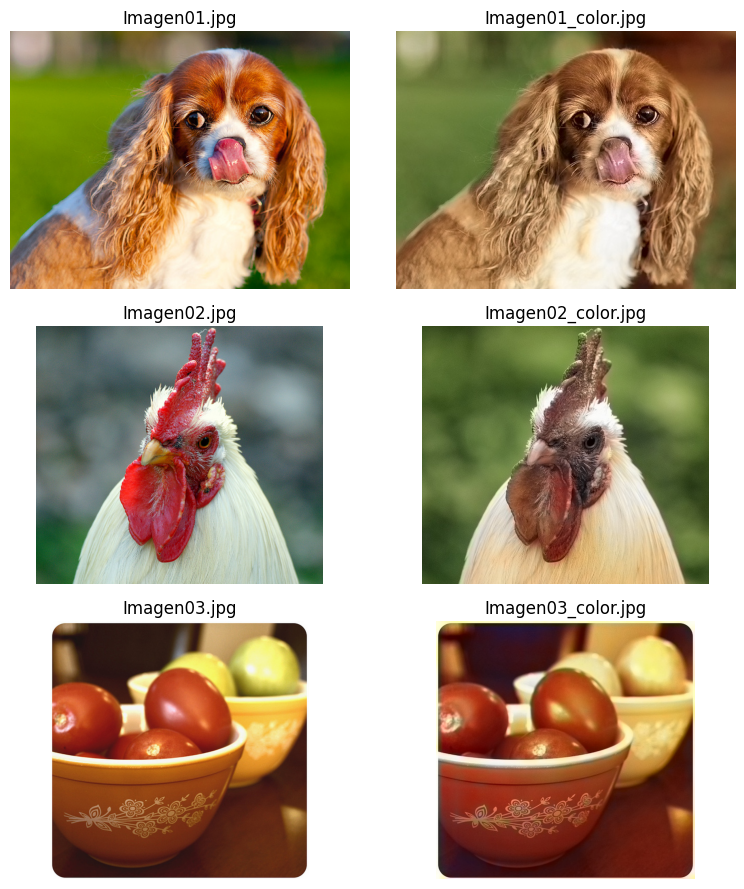

In [8]:
if not pairs:
    print("No hay pares (gt, colorizada). Asegúrate de haber generado las imágenes en imgs_out.")
else:
    N = len(pairs)
    fig, axes = plt.subplots(N, 2, figsize=(8, 3 * N))
    if N == 1:
        axes = np.array([axes])

    for i in range(N):
        raw_p, res_p = pairs[i]
        raw_bgr = cv.imread(str(raw_p))
        res_bgr = cv.imread(str(res_p))

        axes[i, 0].imshow(cv.cvtColor(raw_bgr, cv.COLOR_BGR2RGB)); axes[i, 0].set_title(raw_p.name); axes[i, 0].axis('off')
        axes[i, 1].imshow(cv.cvtColor(res_bgr, cv.COLOR_BGR2RGB)); axes[i, 1].set_title(res_p.name); axes[i, 1].axis('off')

    plt.tight_layout()
    fig_path = EVAL_F / 'mosaic_metrics.png'
    plt.savefig(fig_path, dpi=150)
    print('CSV  ->', csv_path)
    print('FIG  ->', fig_path)

## Visualización de métricas

Creamos diferentes gráficos para analizar visualmente el rendimiento del modelo:

1. **Gráfico de barras agrupadas**: PSNR y SSIM por imagen
2. **Gráfico de dispersión**: Relación entre PSNR y SSIM  
3. **Gráfico de barras horizontales**: Ranking de imágenes por PSNR
4. **Tabla resumen**: Estadísticas descriptivas


In [9]:
# Cargar datos de métricas
df_metrics = pd.read_csv(EVAL_T / 'metrics.csv')

# Preparar nombres más cortos para visualización
df_metrics['imagen_corta'] = df_metrics['imagen'].str.replace('.jpg', '').str.replace('Imagen', 'Img')

print("=== RESUMEN DE MÉTRICAS ===")
print(f"Número de imágenes evaluadas: {len(df_metrics)}")
print(f"\nPSNR promedio: {df_metrics['psnr'].mean():.2f} ± {df_metrics['psnr'].std():.2f} dB")
print(f"SSIM promedio: {df_metrics['ssim'].mean():.3f} ± {df_metrics['ssim'].std():.3f}")
print(f"\nRango PSNR: [{df_metrics['psnr'].min():.2f}, {df_metrics['psnr'].max():.2f}] dB")
print(f"Rango SSIM: [{df_metrics['ssim'].min():.3f}, {df_metrics['ssim'].max():.3f}]")

display(df_metrics)


=== RESUMEN DE MÉTRICAS ===
Número de imágenes evaluadas: 3

PSNR promedio: 20.52 ± 2.90 dB
SSIM promedio: 0.843 ± 0.038

Rango PSNR: [18.22, 23.78] dB
Rango SSIM: [0.818, 0.886]


,imagen,psnr,ssim,imagen_corta
0,Imagen01.jpg,19.558175,0.818306,Img01
1,Imagen02.jpg,18.217422,0.823651,Img02
2,Imagen03.jpg,23.781436,0.885787,Img03


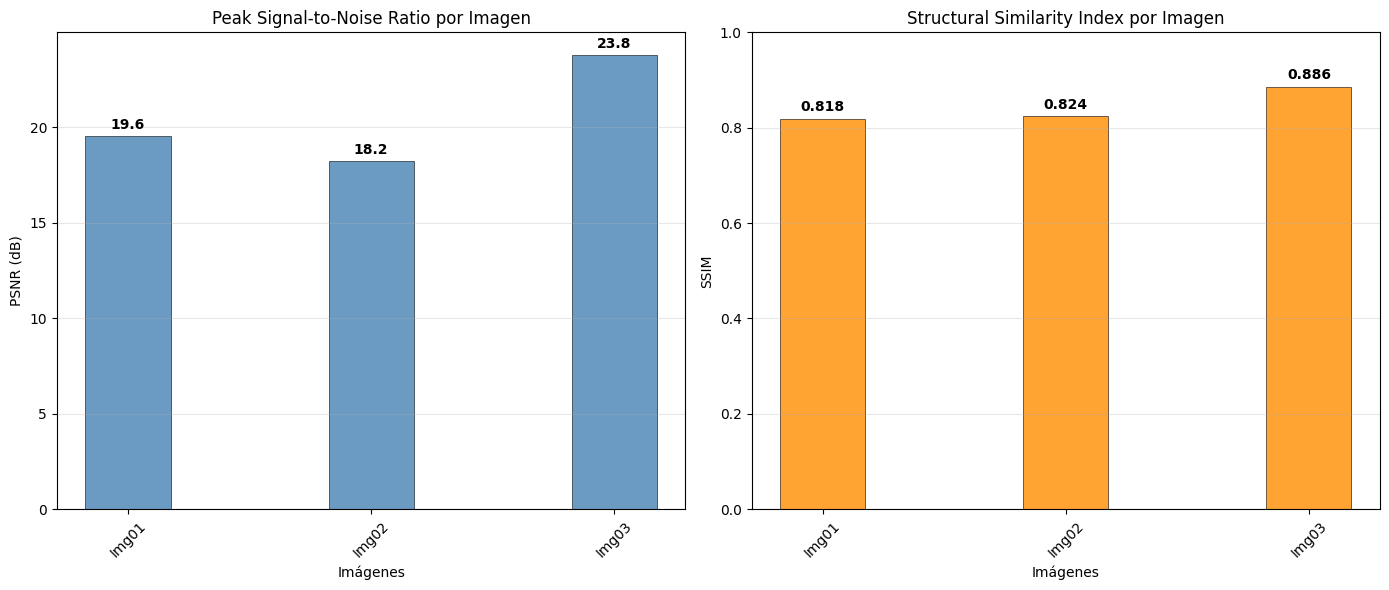

In [10]:
# 1. GRÁFICO DE BARRAS AGRUPADAS (PSNR y SSIM)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Configurar posiciones de las barras
x = np.arange(len(df_metrics))
width = 0.35

# Gráfico 1: PSNR
bars1 = ax1.bar(x, df_metrics['psnr'], width, 
                color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Imágenes')
ax1.set_ylabel('PSNR (dB)')
ax1.set_title('Peak Signal-to-Noise Ratio por Imagen')
ax1.set_xticks(x)
ax1.set_xticklabels(df_metrics['imagen_corta'], rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bar, val in zip(bars1, df_metrics['psnr']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: SSIM
bars2 = ax2.bar(x, df_metrics['ssim'], width,
                color='darkorange', alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Imágenes')
ax2.set_ylabel('SSIM')
ax2.set_title('Structural Similarity Index por Imagen')
ax2.set_xticks(x)
ax2.set_xticklabels(df_metrics['imagen_corta'], rotation=45)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1)

# Añadir valores sobre las barras
for bar, val in zip(bars2, df_metrics['ssim']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(EVAL_F / 'metricas_barras.png', dpi=300, bbox_inches='tight')
plt.show()


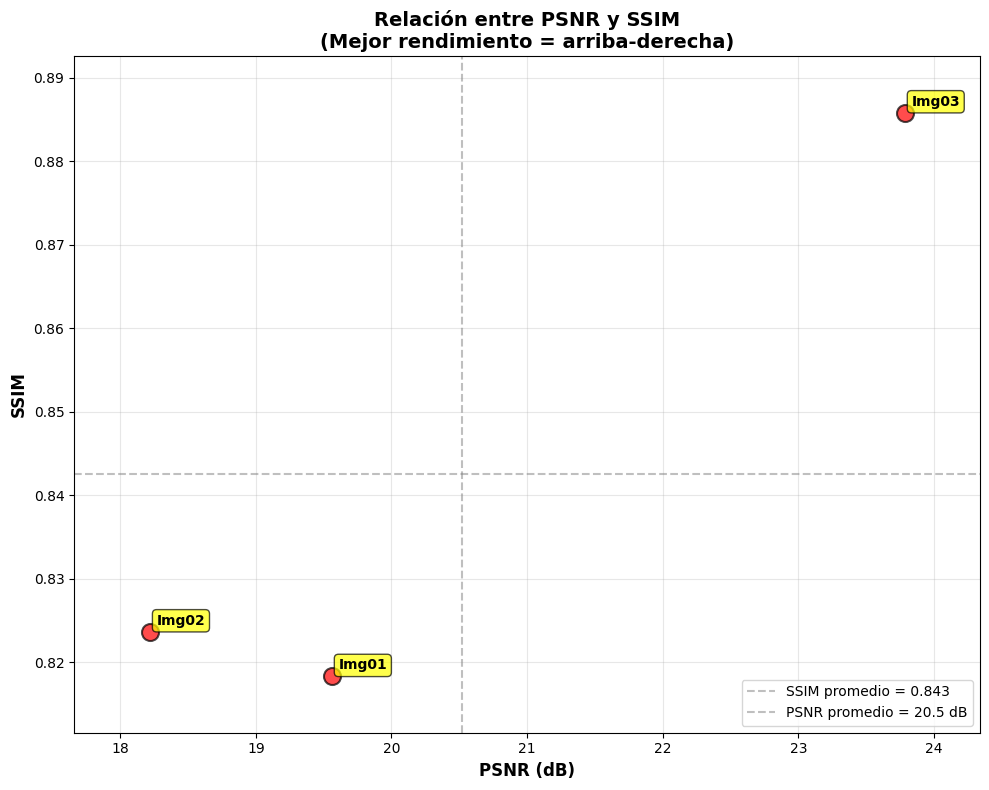

In [11]:
# 2. GRÁFICO DE DISPERSIÓN (PSNR vs SSIM)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Crear scatter plot
scatter = ax.scatter(df_metrics['psnr'], df_metrics['ssim'], 
                    s=150, c='red', alpha=0.7, edgecolors='black', linewidth=1.5)

# Añadir etiquetas para cada punto
for i, row in df_metrics.iterrows():
    ax.annotate(row['imagen_corta'], 
                (row['psnr'], row['ssim']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Configurar ejes y título
ax.set_xlabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax.set_ylabel('SSIM', fontsize=12, fontweight='bold')
ax.set_title('Relación entre PSNR y SSIM\n(Mejor rendimiento = arriba-derecha)', 
             fontsize=14, fontweight='bold')

# Añadir líneas de referencia
ax.axhline(y=df_metrics['ssim'].mean(), color='gray', linestyle='--', alpha=0.5, 
           label=f'SSIM promedio = {df_metrics["ssim"].mean():.3f}')
ax.axvline(x=df_metrics['psnr'].mean(), color='gray', linestyle='--', alpha=0.5,
           label=f'PSNR promedio = {df_metrics["psnr"].mean():.1f} dB')

# Configurar grid y leyenda
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')

# Ajustar límites para mejor visualización
psnr_range = df_metrics['psnr'].max() - df_metrics['psnr'].min()
ssim_range = df_metrics['ssim'].max() - df_metrics['ssim'].min()
ax.set_xlim(df_metrics['psnr'].min() - 0.1*psnr_range, 
            df_metrics['psnr'].max() + 0.1*psnr_range)
ax.set_ylim(df_metrics['ssim'].min() - 0.1*ssim_range, 
            df_metrics['ssim'].max() + 0.1*ssim_range)

plt.tight_layout()
plt.savefig(EVAL_F / 'psnr_vs_ssim.png', dpi=300, bbox_inches='tight')
plt.show()


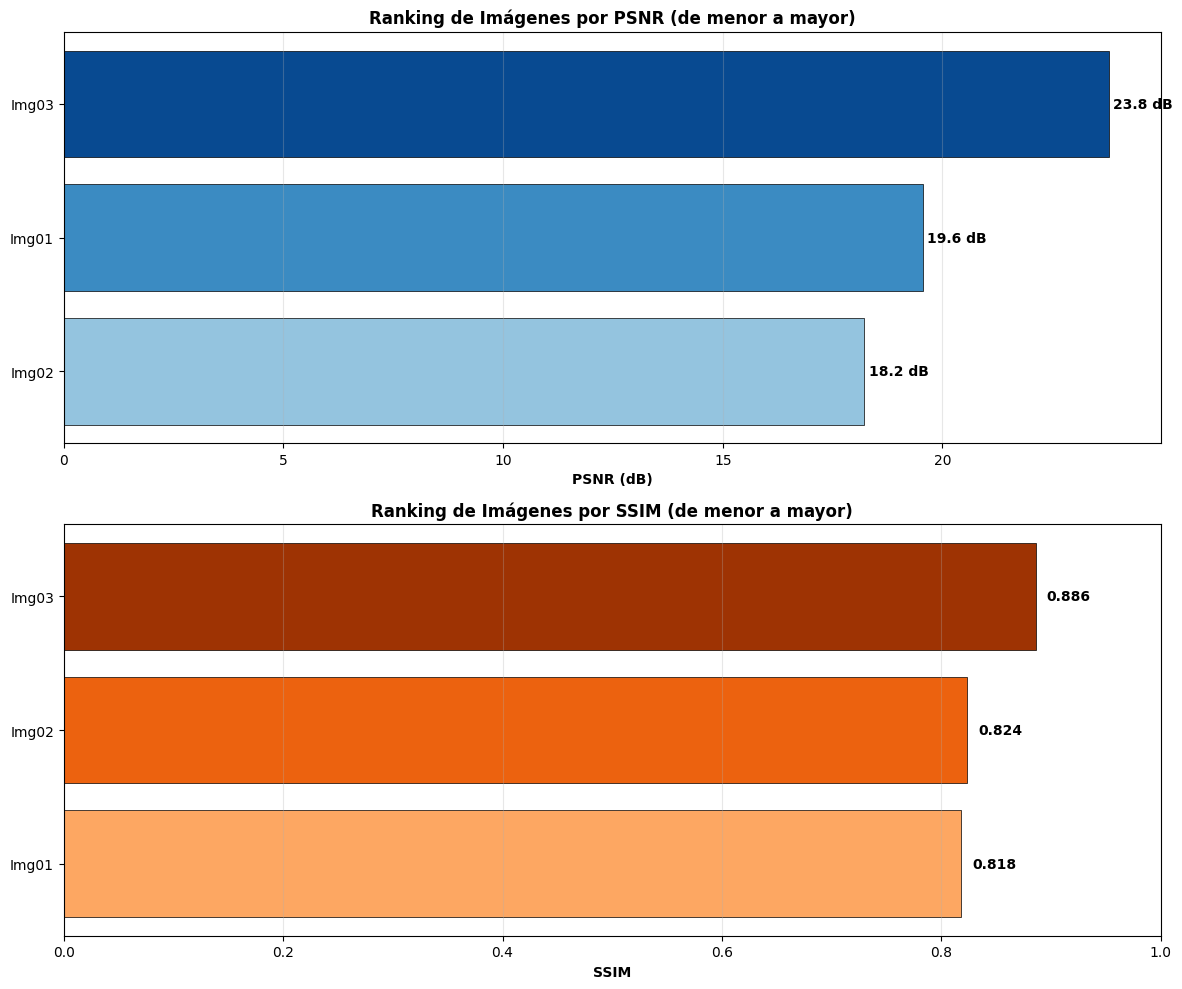

In [12]:
# 3. RANKING DE IMÁGENES (Barras horizontales)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Ordenar por PSNR (descendente)
df_psnr_sorted = df_metrics.sort_values('psnr', ascending=True)
# Ordenar por SSIM (descendente) 
df_ssim_sorted = df_metrics.sort_values('ssim', ascending=True)

# Colores degradados
colors_psnr = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_psnr_sorted)))
colors_ssim = plt.cm.Oranges(np.linspace(0.4, 0.9, len(df_ssim_sorted)))

# Gráfico 1: Ranking por PSNR
bars1 = ax1.barh(df_psnr_sorted['imagen_corta'], df_psnr_sorted['psnr'], 
                 color=colors_psnr, edgecolor='black', linewidth=0.5)
ax1.set_xlabel('PSNR (dB)', fontweight='bold')
ax1.set_title('Ranking de Imágenes por PSNR (de menor a mayor)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Añadir valores al final de cada barra
for i, (bar, val) in enumerate(zip(bars1, df_psnr_sorted['psnr'])):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} dB', va='center', fontweight='bold')

# Gráfico 2: Ranking por SSIM
bars2 = ax2.barh(df_ssim_sorted['imagen_corta'], df_ssim_sorted['ssim'],
                 color=colors_ssim, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('SSIM', fontweight='bold')
ax2.set_title('Ranking de Imágenes por SSIM (de menor a mayor)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(0, 1)

# Añadir valores al final de cada barra
for i, (bar, val) in enumerate(zip(bars2, df_ssim_sorted['ssim'])):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(EVAL_F / 'ranking_metricas.png', dpi=300, bbox_inches='tight')
plt.show()


In [19]:
# 4. TABLA RESUMEN CON ESTADÍSTICAS DESCRIPTIVAS
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")

# Crear tabla de estadísticas con formato directo
stats_data = {
    'Métrica': ['PSNR (dB)', 'SSIM'],
    'Media': [round(df_metrics['psnr'].mean(), 2), round(df_metrics['ssim'].mean(), 4)],
    'Mediana': [round(df_metrics['psnr'].median(), 2), round(df_metrics['ssim'].median(), 4)],
    'Desv. Estándar': [round(df_metrics['psnr'].std(), 2), round(df_metrics['ssim'].std(), 4)],
    'Mínimo': [round(df_metrics['psnr'].min(), 2), round(df_metrics['ssim'].min(), 4)],
    'Máximo': [round(df_metrics['psnr'].max(), 2), round(df_metrics['ssim'].max(), 4)],
    'Rango': [round(df_metrics['psnr'].max() - df_metrics['psnr'].min(), 2), 
              round(df_metrics['ssim'].max() - df_metrics['ssim'].min(), 4)]
}

df_stats = pd.DataFrame(stats_data)

display(df_stats)

# Interpretación de resultados
print("\n=== INTERPRETACIÓN DE RESULTADOS ===")
print(" PSNR (Peak Signal-to-Noise Ratio):")
print(f"   • Rango típico: 20-40 dB (valores más altos = mejor calidad)")
print(f"   • Tu promedio: {df_metrics['psnr'].mean():.1f} dB")
if df_metrics['psnr'].mean() >= 25:
    print("    Calidad BUENA")
elif df_metrics['psnr'].mean() >= 20:
    print("     Calidad ACEPTABLE")
else:
    print("    Calidad BAJA")

print(f"\nSSIM (Structural Similarity Index):")
print(f"   • Rango: 0-1 (valores más altos = mejor similitud estructural)")
print(f"   • Tu promedio: {df_metrics['ssim'].mean():.3f}")
if df_metrics['ssim'].mean() >= 0.9:
    print("   Similitud EXCELENTE")
elif df_metrics['ssim'].mean() >= 0.8:
    print("   Similitud BUENA")
elif df_metrics['ssim'].mean() >= 0.7:
    print("   Similitud ACEPTABLE")
else:
    print("   Similitud BAJA")

# Identificar mejor y peor imagen
best_psnr_idx = df_metrics['psnr'].idxmax()
worst_psnr_idx = df_metrics['psnr'].idxmin()
best_ssim_idx = df_metrics['ssim'].idxmax()
worst_ssim_idx = df_metrics['ssim'].idxmin()

print(f"\nMEJOR RENDIMIENTO:")
print(f"   • PSNR: {df_metrics.loc[best_psnr_idx, 'imagen']} ({df_metrics.loc[best_psnr_idx, 'psnr']:.1f} dB)")
print(f"   • SSIM: {df_metrics.loc[best_ssim_idx, 'imagen']} ({df_metrics.loc[best_ssim_idx, 'ssim']:.3f})")

print(f"\nPEOR RENDIMIENTO:")
print(f"   • PSNR: {df_metrics.loc[worst_psnr_idx, 'imagen']} ({df_metrics.loc[worst_psnr_idx, 'psnr']:.1f} dB)")
print(f"   • SSIM: {df_metrics.loc[worst_ssim_idx, 'imagen']} ({df_metrics.loc[worst_ssim_idx, 'ssim']:.3f})")

print(f"\nGráficos guardados en: {EVAL_F}")
print("   • metricas_barras.png")
print("   • psnr_vs_ssim.png") 
print("   • ranking_metricas.png")


=== ESTADÍSTICAS DESCRIPTIVAS ===


,Métrica,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Rango
0,PSNR (dB),20.5200,19.5600,2.9000,18.2200,23.7800,5.5600
1,SSIM,0.8426,0.8237,0.0375,0.8183,0.8858,0.0675



=== INTERPRETACIÓN DE RESULTADOS ===
 PSNR (Peak Signal-to-Noise Ratio):
   • Rango típico: 20-40 dB (valores más altos = mejor calidad)
   • Tu promedio: 20.5 dB
     Calidad ACEPTABLE

SSIM (Structural Similarity Index):
   • Rango: 0-1 (valores más altos = mejor similitud estructural)
   • Tu promedio: 0.843
   Similitud BUENA

MEJOR RENDIMIENTO:
   • PSNR: Imagen03.jpg (23.8 dB)
   • SSIM: Imagen03.jpg (0.886)

PEOR RENDIMIENTO:
   • PSNR: Imagen02.jpg (18.2 dB)
   • SSIM: Imagen01.jpg (0.818)

Gráficos guardados en: C:\Users\ander\Desktop\PID\Proyecto\eval\figs
   • metricas_barras.png
   • psnr_vs_ssim.png
   • ranking_metricas.png
